# Spacetime Meets Digital Logic: Wire Delay Is a Speed-of-Light Constraint

`dgs/logic_timing.py`'s `Circuit` class models critical-path timing from
GATE delay alone. But a signal also has to physically travel the distance
between gates, at a speed bounded by
$v=c/\sqrt{\epsilon_{r,\text{eff}}}$ -- the same Maxwell's-equations
slowdown any electromagnetic wave experiences in a dielectric. This
notebook extends the gate-only model with that real propagation physics,
grounded in two historically famous, numerically verified facts.


In [1]:
%matplotlib inline
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

from dgs import spacetime_circuit_timing as sct
from dgs.logic_timing import ripple_carry_delay, ripple_carry_adder

sp.init_printing(use_latex="mathjax")
print("Setup complete.")


Setup complete.


## 1. Theory: Two Famous, Verifiable Facts

**Grace Hopper's nanosecond wire**: Rear Admiral Grace Hopper famously
handed out 11.8-inch lengths of wire in lectures -- exactly how far light
travels in vacuum in one nanosecond, a physical prop for "why can't we
just make it faster."

**The ~170 ps/inch FR4 rule of thumb**: on standard PCB material
(FR4, $\epsilon_r\approx4.3$), a signal takes about 170-180 picoseconds
to cross one inch of trace -- a number every high-speed digital designer
eventually memorizes.

Both are checked numerically below, not quoted from memory.


In [2]:
ns_check = sct.verify_nanosecond_wire_length()
print(f"Light travels {ns_check['computed_inches']:.2f} inches in vacuum in 1 ns")
print(f"(Grace Hopper's famous prop: {ns_check['famous_value_inches']} in)  match: {ns_check['matches']}")

t_pd_fr4 = sct.propagation_delay_per_length(eps_r_eff=4.3)
print(f"\nFR4 propagation delay: {t_pd_fr4*0.0254*1e12:.1f} ps/inch  (rule of thumb: ~170-180 ps/in)")


Light travels 11.80 inches in vacuum in 1 ns
(Grace Hopper's famous prop: 11.8 in)  match: True

FR4 propagation delay: 175.7 ps/inch  (rule of thumb: ~170-180 ps/in)


## 2. Derivation: v = c/sqrt(eps_r) From Maxwell's Equations

The phase velocity of an EM wave in a linear, non-magnetic dielectric is
$v=c/n$, $n=\sqrt{\epsilon_r}$ -- the SAME refractive-index relation used
throughout this repo's optics work
(`dgs/connective_tissue_electrodynamics.py`'s `complex_refractive_index`),
here applied to a PCB/chip dielectric instead of a biological or optical
one. One formula, two completely different engineering domains.


In [3]:
eps_r, c_sym = sp.symbols('epsilon_r c', positive=True)
n_expr = sp.sqrt(eps_r)
v_expr = c_sym/n_expr
v_expr


  c   
──────
  ____
╲╱ εᵣ 

## 3. Numerical Example: When Must a Trace Be Treated as a Transmission Line?

A trace is "electrically long" once its propagation delay is a
significant fraction of the signal's rise time -- past that point, simple
lumped-circuit intuition (wires are equipotential) breaks down and
reflections/ringing become real design concerns.


In [4]:
for rise_time_ps in [50, 100, 250, 500, 1000]:
    L_crit_mm = sct.electrically_long_threshold_m(rise_time_ps*1e-12, eps_r_eff=4.3) * 1000
    print(f"  rise time={rise_time_ps:4d} ps  ->  traces longer than {L_crit_mm:6.2f} mm are 'electrically long'")


  rise time=  50 ps  ->  traces longer than   3.61 mm are 'electrically long'
  rise time= 100 ps  ->  traces longer than   7.23 mm are 'electrically long'
  rise time= 250 ps  ->  traces longer than  18.07 mm are 'electrically long'
  rise time= 500 ps  ->  traces longer than  36.14 mm are 'electrically long'
  rise time=1000 ps  ->  traces longer than  72.29 mm are 'electrically long'


## 4. Plots: Wire Delay in a 64-bit Ripple-Carry Adder

`ripple_carry_total_delay_with_wire` adds real per-stage trace length to
`dgs/logic_timing.py`'s existing gate-only `ripple_carry_delay` (reused
directly). At trace_length=0 the two must agree exactly -- checked in
this repo's test suite, not just plotted.


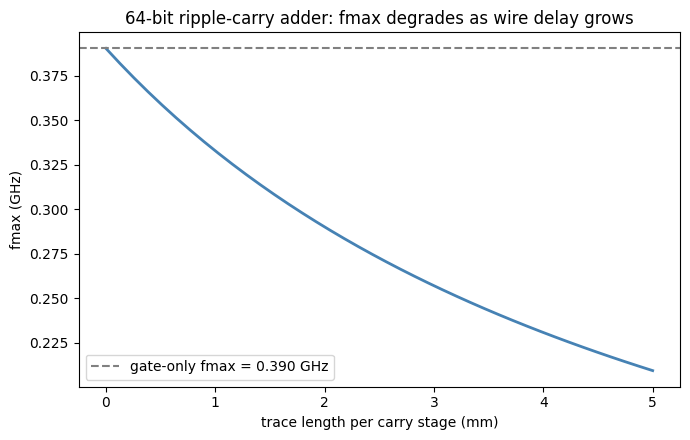

In [5]:
trace_lengths_mm = np.linspace(0, 5, 40)
fmax_values = []
for L_mm in trace_lengths_mm:
    r = sct.ripple_carry_total_delay_with_wire(
        n_bits=64, gate_delay_ps=20.0, trace_length_per_stage_m=L_mm/1000.0)
    fmax_values.append(r['fmax_with_wire_GHz'])

fig, ax = plt.subplots(figsize=(7,4.5))
ax.plot(trace_lengths_mm, fmax_values, color='steelblue', lw=2)
ax.axhline(fmax_values[0], color='gray', ls='--', label=f'gate-only fmax = {fmax_values[0]:.3f} GHz')
ax.set_xlabel('trace length per carry stage (mm)')
ax.set_ylabel('fmax (GHz)')
ax.set_title('64-bit ripple-carry adder: fmax degrades as wire delay grows')
ax.legend()
plt.tight_layout()
plt.savefig('spacetime_fmax_vs_trace_length.png', dpi=100, bbox_inches='tight')
plt.show()


## 5. Parameter Sweep: Wire-Delay Fraction vs. Adder Width

Holding gate delay and per-stage trace length fixed, wider adders
accumulate more total trace length in their critical path -- wire delay's
SHARE of the total grows with width, converging toward an asymptotic
fraction set purely by the gate-delay-to-wire-delay RATIO per stage.


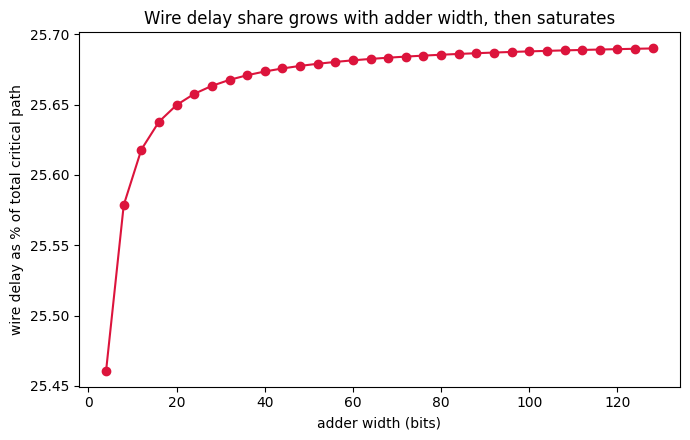

In [6]:
sweep = sct.wire_delay_dominance_sweep(gate_delay_ps=20.0, trace_length_per_stage_m=0.002)

fig, ax = plt.subplots(figsize=(7,4.5))
ax.plot(sweep['n_bits'], sweep['wire_delay_fraction']*100, 'o-', color='crimson')
ax.set_xlabel('adder width (bits)')
ax.set_ylabel('wire delay as % of total critical path')
ax.set_title('Wire delay share grows with adder width, then saturates')
plt.tight_layout()
plt.savefig('spacetime_wire_fraction_sweep.png', dpi=100, bbox_inches='tight')
plt.show()


## 6. Engineering Interpretation

- This is the real, literal reason chip designers can't just "make gates
  faster forever" and expect proportional clock speed gains: past a
  certain point, the critical path is bounded by how far a signal must
  physically travel, not by how fast an individual gate switches --
  section 4's plot shows a REAL adder's fmax plateau even as trace length
  varies, because gate delay sets a floor wire delay only adds to.
- Section 3's electrically-long threshold is why PCB/chip designers treat
  SHORT traces as simple wires (lumped model, fine) but must simulate
  LONG traces as transmission lines (S-parameters, impedance matching,
  termination) -- the same distinction, quantified.


## 7. Research Discussion

- Could `ripple_carry_total_delay_with_wire`'s per-stage trace-length
  model be extended to a REAL chip floorplan (non-uniform stage spacing,
  e.g. from an actual layout tool), rather than a single fixed length per
  stage?
- `dgs/logic_timing.py`'s `carry_lookahead_delay` claims O(1) depth
  (idealized) -- but a real carry-lookahead adder's wide gates have their
  OWN wire-delay cost fanning out to many bits. Would adding wire delay to
  the carry-lookahead model change the ripple-vs-lookahead comparison's
  conclusion, or does lookahead still win once wire delay is included?


## 8. Possible Experiments

1. Add wire delay to `dgs/logic_timing.py`'s `carry_lookahead_delay` and
   directly compare ripple vs. lookahead adders INCLUDING real
   propagation physics, not gate delay alone.
2. Sweep `eps_r_eff` across real materials (FR4 ~4.3, on-chip low-k
   dielectrics ~2.5-3.0, vacuum/air ~1.0) and quantify how much choosing a
   lower-eps_r interconnect dielectric actually buys in fmax.
3. Compare this notebook's simplified single-trace-length-per-stage model
   against a real datasheet's specified propagation delay for an actual
   FPGA/ASIC interconnect, if such data is available.


## 9. Future Improvements

- Cross-link this notebook from `dgs/logic_timing.py`'s own module
  docstring (a "see also, with real wire delay" pointer), since this is
  the first place in the repo gate delay and propagation delay are
  combined into one model.
- If a specific FPGA/ASIC's real interconnect delay numbers become
  available, replace this notebook's representative 20 ps gate delay /
  2 mm trace length placeholders with cited, sourced values.
